In [68]:
import pandas as pd
import sqlite3
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.formula.api import logit
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score,
    f1_score, log_loss
)

In [11]:
df = pd.read_csv(r"C:\Users\Admin\OneDrive - RMIT University\Desktop\Data Science\Crash Severity Analysis\artifacts\processed.csv")
df.head()

,Unnamed: 0,accident_type,day_of_week,dca_code,no_of_vehicles,police_attended,road_geometry,light_condition,speed_zone,severity,node_type,deg_urban_name,road_type,total_vehicles,max_vehicle_damage,total_persons,year,month,hour
0,0,4,1,171,1,1,5,5,100.0,0,N,RURAL_VICTORIA,ROAD,1,5.0,2,2012,1,2
1,1,1,1,110,2,1,1,3,80.0,0,N,MELB_URBAN,ROAD,2,4.0,3,2012,1,2
2,2,1,1,160,2,1,2,3,60.0,0,I,MELB_URBAN,ROAD,2,4.0,1,2012,1,3
3,3,4,1,173,1,1,1,5,100.0,0,I,RURAL_VICTORIA,HIGHWAY,1,5.0,1,2012,1,5
4,4,4,1,171,1,1,5,1,50.0,0,N,MELB_URBAN,ROAD,1,3.0,3,2012,1,7


In [12]:
df["severity"].value_counts()

severity
0    188572
1      3207
Name: count, dtype: int64

In [13]:
df["severity"].value_counts()[1]/df["severity"].value_counts()[0]

0.01700676664616168

From the above output, Severit = 1(fatal) represents only 1.7% of the data

In [14]:
df.dtypes

Unnamed: 0              int64
accident_type           int64
day_of_week             int64
dca_code               object
no_of_vehicles          int64
police_attended         int64
road_geometry           int64
light_condition         int64
speed_zone            float64
severity                int64
node_type              object
deg_urban_name         object
road_type              object
total_vehicles          int64
max_vehicle_damage    float64
total_persons           int64
year                    int64
month                   int64
hour                    int64
dtype: object

In [15]:
df = df.iloc[:, 1:]
df.head()

,accident_type,day_of_week,dca_code,no_of_vehicles,police_attended,road_geometry,light_condition,speed_zone,severity,node_type,deg_urban_name,road_type,total_vehicles,max_vehicle_damage,total_persons,year,month,hour
0,4,1,171,1,1,5,5,100.0,0,N,RURAL_VICTORIA,ROAD,1,5.0,2,2012,1,2
1,1,1,110,2,1,1,3,80.0,0,N,MELB_URBAN,ROAD,2,4.0,3,2012,1,2
2,1,1,160,2,1,2,3,60.0,0,I,MELB_URBAN,ROAD,2,4.0,1,2012,1,3
3,4,1,173,1,1,1,5,100.0,0,I,RURAL_VICTORIA,HIGHWAY,1,5.0,1,2012,1,5
4,4,1,171,1,1,5,1,50.0,0,N,MELB_URBAN,ROAD,1,3.0,3,2012,1,7


In [ ]:
#skew and kurtosis
num_cols = df.select_dtypes(include=np.number).columns.drop("severity")
 
print(df[num_cols].skew().sort_values(ascending=False))
print(df[num_cols].kurtosis().sort_values(ascending=False))

total_persons         8.484138
light_condition       2.554985
no_of_vehicles        1.657611
total_vehicles        1.657329
accident_type         1.637250
police_attended       1.096897
speed_zone            0.716463
max_vehicle_damage    0.628796
month                 0.086566
year                  0.026900
day_of_week          -0.070176
road_geometry        -0.217865
hour                 -0.336204
dtype: float64
total_persons         330.794433
no_of_vehicles         10.619997
total_vehicles         10.617488
light_condition         7.060512
accident_type           1.710307
max_vehicle_damage     -0.063265
hour                   -0.357277
speed_zone             -0.391617
police_attended        -0.796825
day_of_week            -1.105272
year                   -1.232884
month                  -1.244101
road_geometry          -1.666980
dtype: float64


In [22]:
TARGET = "severity"
 
# columns to exclude from EDA (IDs, dates, target)
EXCLUDE = ["accident_no", "accident_date", "accident_time", TARGET]
 
num_cols = [c for c in df.select_dtypes(include=np.number).columns if c not in EXCLUDE]
cat_cols = [c for c in df.select_dtypes(include="category").columns if c not in EXCLUDE]



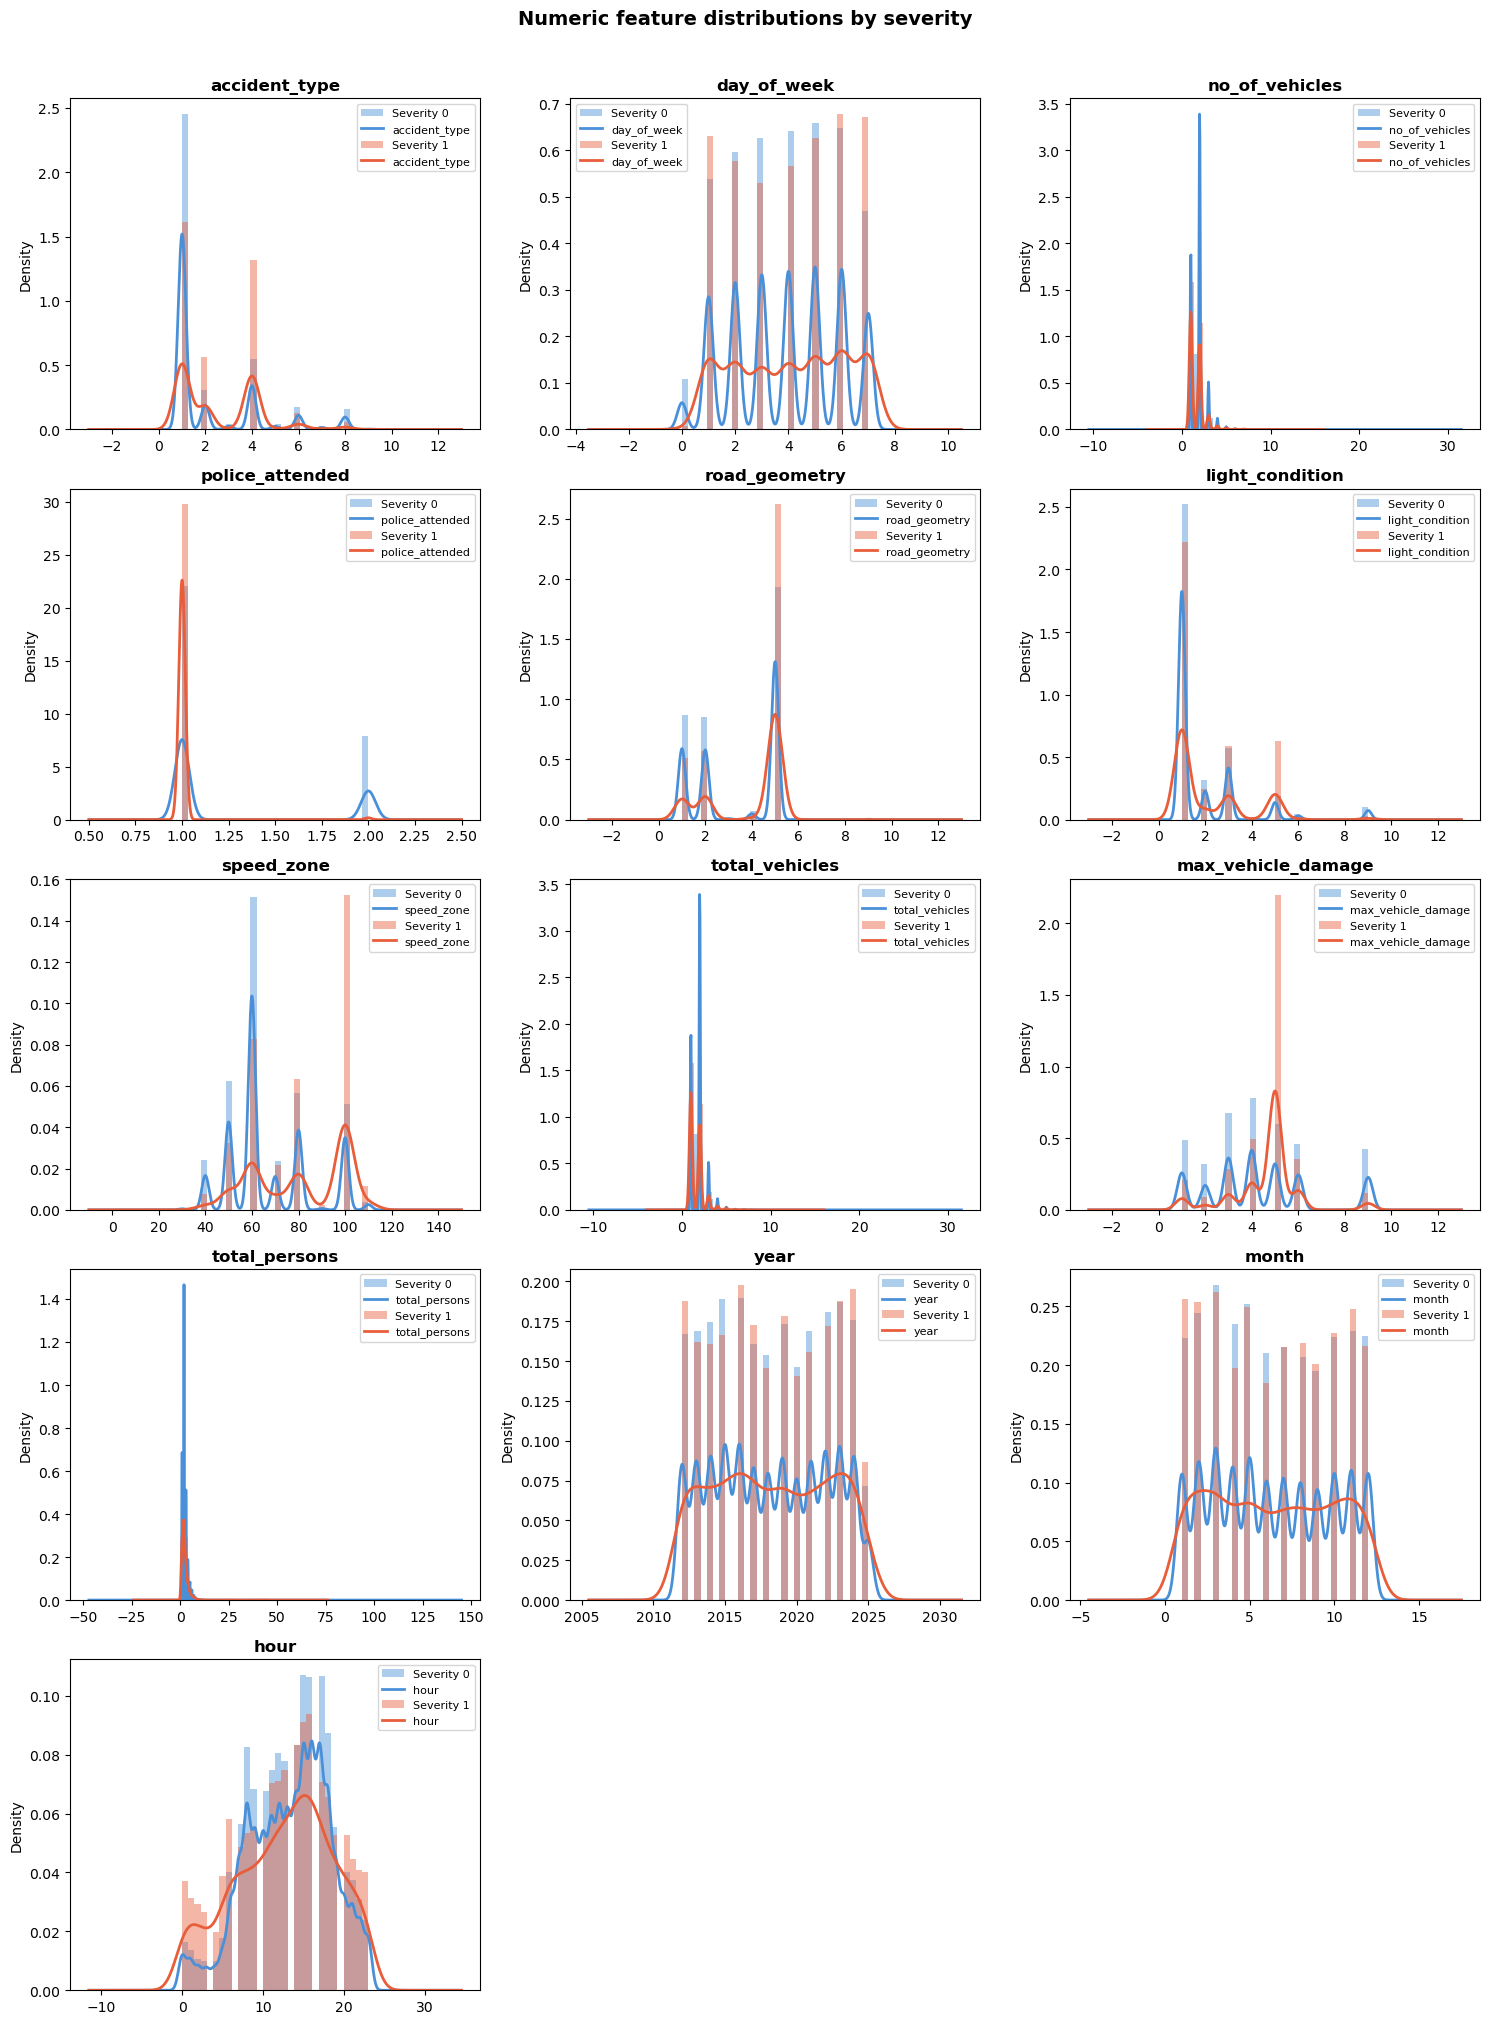

In [23]:
#KDE

ncols = 3
nrows = (len(num_cols) + ncols - 1) // ncols
 
fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 4))
axes = axes.flatten()
 
for i, col in enumerate(num_cols):
    for cls, color in zip([0, 1], ["#4A90D9", "#E85D3A"]):
        subset = df[df[TARGET] == cls][col].dropna()
        axes[i].hist(subset, bins=30, alpha=0.45, color=color, density=True, label=f"Severity {cls}")
        subset.plot.kde(ax=axes[i], color=color, linewidth=2)
    axes[i].set_title(col, fontweight="bold")
    axes[i].legend(fontsize=8)
 
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
 
plt.suptitle("Numeric feature distributions by severity", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()
 

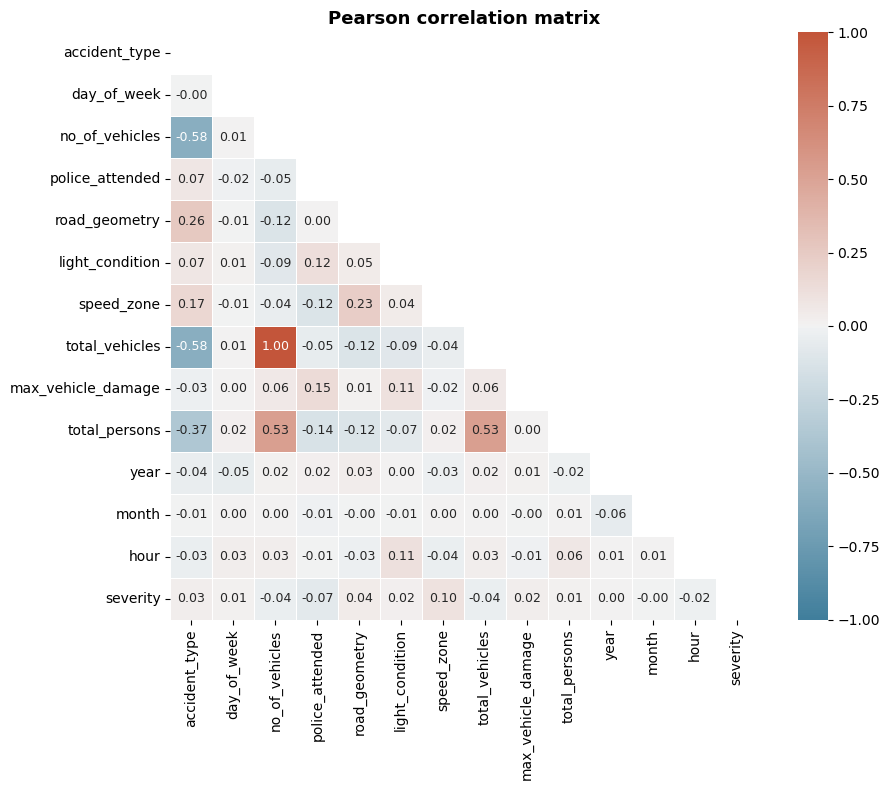

In [24]:
# correlation

corr = df[num_cols + [TARGET]].corr()
 
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f",
    cmap=sns.diverging_palette(230, 20, as_cmap=True),
    center=0, square=True, linewidths=0.5,
    annot_kws={"size": 9}, ax=ax, vmin=-1, vmax=1
)
ax.set_title("Pearson correlation matrix", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [25]:
print("High correlations (|r| >= 0.7):")
for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        if abs(corr.iloc[i, j]) >= 0.7:
            print(f"  {corr.columns[i]} vs {corr.columns[j]}: r = {corr.iloc[i, j]:.3f}")

High correlations (|r| >= 0.7):
  no_of_vehicles vs total_vehicles: r = 1.000


In [40]:
features = [
    "accident_type", "day_of_week", "dca_code",
    "road_geometry", "light_condition", "speed_zone", "road_type",
    "hour", "month", "year", "deg_urban_name"
]

In [41]:
df["dca_code"] = df["dca_code"].replace("OTHER", 0).astype(int).astype("category")
df.dtypes

accident_type            int64
day_of_week              int64
dca_code              category
no_of_vehicles           int64
police_attended          int64
road_geometry            int64
light_condition          int64
speed_zone             float64
severity                 int64
node_type               object
deg_urban_name          object
road_type               object
total_vehicles           int64
max_vehicle_damage     float64
total_persons            int64
year                     int64
month                    int64
hour                     int64
dtype: object

In [ ]:
print(df["road_type"].dtype)
df["road_type"] = df["road_type"].astype("category")
print(df["road_type"].dtype)

object
category


In [51]:
df["deg_urban_name"] = df["deg_urban_name"].astype("category")

In [52]:
X = df[features].dropna().copy()

for col in X.columns:
    if hasattr(X[col], "cat"):
        X[col] = X[col].cat.codes.astype(float)
    else:
        X[col] = X[col].astype(float)

print(X.dtypes)

accident_type      float64
day_of_week        float64
dca_code           float64
road_geometry      float64
light_condition    float64
speed_zone         float64
road_type          float64
hour               float64
month              float64
year               float64
deg_urban_name     float64
dtype: object


In [66]:
features = [
    "accident_type", "day_of_week", "dca_code", "light_condition", "speed_zone",
    "deg_urban_name", #"total_vehicles", 
    "hour", "month"
]

        feature       VIF
     speed_zone 10.796838
           hour  6.252007
 deg_urban_name  5.508104
    day_of_week  4.276682
          month  3.909792
       dca_code  3.231451
  accident_type  2.813057
light_condition  2.284629


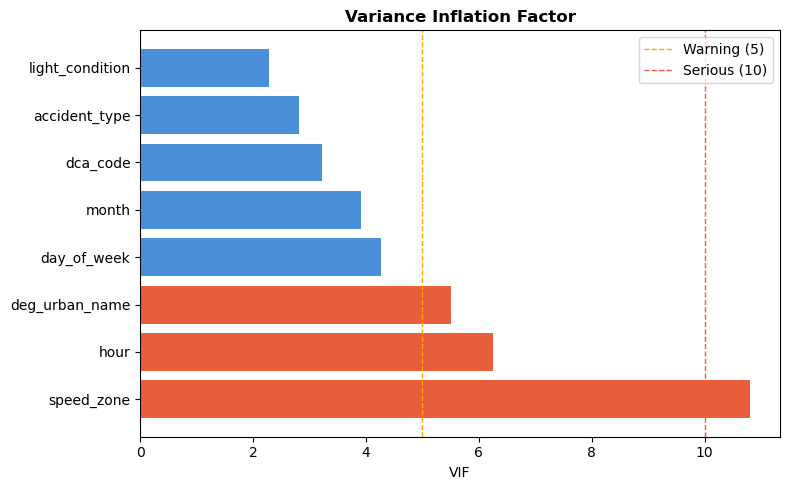

In [67]:
X = df[features].dropna().copy()
X = X.apply(lambda col: col.cat.codes if hasattr(col, "cat") else col)
 
vif_df = pd.DataFrame()
vif_df["feature"] = X.columns
vif_df["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_df = vif_df.sort_values("VIF", ascending=False).reset_index(drop=True)
 
print(vif_df.to_string(index=False))
# Rule of thumb: VIF > 5 = warning, VIF > 10 = serious multicollinearity
 
# Visual
fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#E85D3A" if v > 5 else "#4A90D9" for v in vif_df["VIF"]]
ax.barh(vif_df["feature"], vif_df["VIF"], color=colors)
ax.axvline(5,  color="orange", linestyle="--", linewidth=1, label="Warning (5)")
ax.axvline(10, color="#E85D3A", linestyle="--", linewidth=1, label="Serious (10)")
ax.set_xlabel("VIF")
ax.set_title("Variance Inflation Factor", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

In [69]:
TARGET = "severity"
 
features = [
    "accident_type", "day_of_week", "dca_code",
    "light_condition", "speed_zone",
    "deg_urban_name", "hour", "month"
]
 
# =============================================================
# 1. Prepare data
# =============================================================
 
# one-hot encode
df_model = pd.get_dummies(df[features + [TARGET]], drop_first=True)
 
X = df_model.drop(columns=TARGET)
y = df_model[TARGET]
 
print("Feature matrix shape:", X.shape)
print("Class distribution:\n", y.value_counts())
 
# stratified split — preserves 1.7% minority in both train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
 
print(f"\nTrain size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")
print(f"Train severity rate: {y_train.mean():.4f}")
print(f"Test severity rate:  {y_test.mean():.4f}")
 
# scale — important for logistic regression coefficients to be comparable
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)   # fit only on train, transform test
 
# =============================================================
# 2. Model WITHOUT SMOTE (baseline)
# =============================================================
 
model_base = LogisticRegression(
    class_weight="balanced",   # compensates for imbalance without resampling
    max_iter=1000,
    solver="saga",             # handles large datasets + supports L1/L2
    random_state=42
)
 
model_base.fit(X_train_scaled, y_train)
 
# predictions
y_pred_base  = model_base.predict(X_test_scaled)
y_prob_base  = model_base.predict_proba(X_test_scaled)[:, 1]
 
print("\n" + "=" * 50)
print("BASELINE MODEL (no SMOTE, class_weight='balanced')")
print("=" * 50)
print(classification_report(y_test, y_pred_base, digits=4))
print(f"ROC-AUC:  {roc_auc_score(y_test, y_prob_base):.4f}")
print(f"PR-AUC:   {average_precision_score(y_test, y_prob_base):.4f}")
print(f"Log-loss: {log_loss(y_test, y_prob_base):.4f}")
 

Feature matrix shape: (191779, 38)
Class distribution:
 severity
0    188572
1      3207
Name: count, dtype: int64

Train size: 153423 | Test size: 38356
Train severity rate: 0.0167
Test severity rate:  0.0167


c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(



BASELINE MODEL (no SMOTE, class_weight='balanced')
              precision    recall  f1-score   support

           0     0.9928    0.7360    0.8453     37715
           1     0.0422    0.6849    0.0796       641

    accuracy                         0.7352     38356
   macro avg     0.5175    0.7105    0.4625     38356
weighted avg     0.9769    0.7352    0.8326     38356

ROC-AUC:  0.7566
PR-AUC:   0.0497
Log-loss: 0.6215


In [70]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

In [71]:
smote_pipeline = ImbPipeline([
    ("smote",  SMOTE(random_state=42, k_neighbors=5)),
    ("scaler", StandardScaler()),
    ("model",  LogisticRegression(max_iter=1000, solver="saga", random_state=42))
])
 
smote_pipeline.fit(X_train, y_train)
 
y_pred_smote = smote_pipeline.predict(X_test)
y_prob_smote = smote_pipeline.predict_proba(X_test)[:, 1]
 
print("\n" + "=" * 50)
print("SMOTE MODEL")
print("=" * 50)
print(classification_report(y_test, y_pred_smote, digits=4))
print(f"ROC-AUC:  {roc_auc_score(y_test, y_prob_smote):.4f}")
print(f"PR-AUC:   {average_precision_score(y_test, y_prob_smote):.4f}")
print(f"Log-loss: {log_loss(y_test, y_prob_smote):.4f}")
 
# Check SMOTE class balance after resampling
X_res, y_res = smote_pipeline.named_steps["smote"].fit_resample(X_train, y_train)
print(f"\nAfter SMOTE — class distribution in training set:")
print(pd.Series(y_res).value_counts())
 
# =============================================================
# 4. Stratified cross-validation (SMOTE model)
# =============================================================
# Use imblearn Pipeline so SMOTE is applied per fold correctly
 
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
 
cv_roc = cross_val_score(smote_pipeline, X_train, y_train, cv=cv, scoring="roc_auc")
cv_pr  = cross_val_score(smote_pipeline, X_train, y_train, cv=cv, scoring="average_precision")
cv_f1  = cross_val_score(smote_pipeline, X_train, y_train, cv=cv, scoring="f1")
 
print("\n5-Fold Stratified CV (SMOTE model):")
print(f"  ROC-AUC : {cv_roc.mean():.4f} ± {cv_roc.std():.4f}")
print(f"  PR-AUC  : {cv_pr.mean():.4f}  ± {cv_pr.std():.4f}")
print(f"  F1      : {cv_f1.mean():.4f}  ± {cv_f1.std():.4f}")

c:\Users\Admin\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\Admin\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\Admin\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Admin\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\Admin\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreatePro


SMOTE MODEL
              precision    recall  f1-score   support

           0     0.9904    0.8623    0.9219     37715
           1     0.0591    0.5086    0.1059       641

    accuracy                         0.8564     38356
   macro avg     0.5247    0.6855    0.5139     38356
weighted avg     0.9748    0.8564    0.9083     38356

ROC-AUC:  0.7316
PR-AUC:   0.0775
Log-loss: 0.3131

After SMOTE — class distribution in training set:
severity
0    150857
1    150857
Name: count, dtype: int64

5-Fold Stratified CV (SMOTE model):
  ROC-AUC : 0.7200 ± 0.0121
  PR-AUC  : 0.0743  ± 0.0092
  F1      : 0.1041  ± 0.0021
